In [1]:
import os
import torch
import torchaudio
import torchaudio.transforms as tt
import matplotlib.pyplot as plt
import pandas as pd
import pyroomacoustics as pra

In [2]:
path_db = r"/home/ovistetom/Documents/data/MIX-EARS-WHAM/reference/tst"

In [3]:
file_path = os.path.join(path_db, '00001', 'target_speech.flac')
waveform, sr = torchaudio.load(file_path)

In [4]:
print(waveform.shape)
waveform = waveform.mean(dim=0)
print(waveform.shape)

torch.Size([4, 165698])
torch.Size([165698])


In [5]:
spectrum = torch.fft.rfft(waveform).abs()
print(spectrum.shape)

torch.Size([82850])


torch.Size([82850])


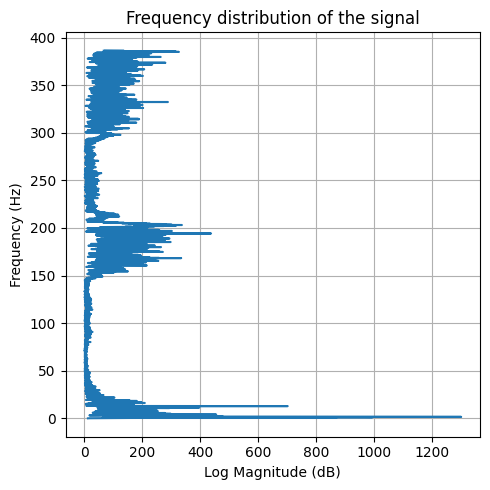

In [6]:
fft_freqs = torch.fft.rfftfreq(waveform.size(0), d=1/sr)
print(fft_freqs.shape)

fig, axs = plt.subplots(1, 1, figsize=(5, 5))

axs.plot(spectrum.abs()[:4000], fft_freqs[:4000])
axs.set_xlabel("Log Magnitude (dB)")
axs.set_ylabel("Frequency (Hz)")
axs.set_title("Frequency distribution of the signal")

axs.grid()
fig.tight_layout()
plt.show()

Filtering?

In [129]:
filtered_waveform = torchaudio.functional.highpass_biquad(waveform, sample_rate=sr, cutoff_freq=60.0)
filtered_spectrum = torch.fft.rfft(filtered_waveform).abs()

torch.Size([82850])


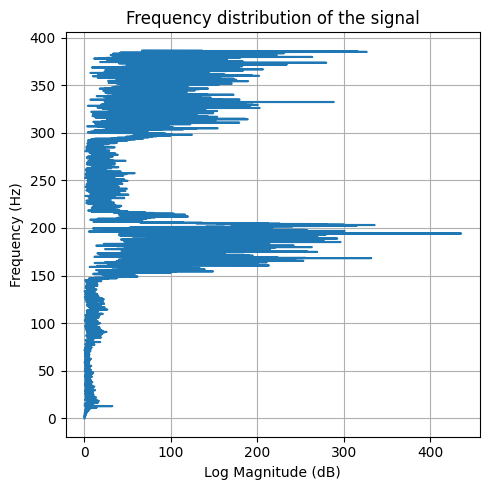

In [130]:
fft_freqs = torch.fft.rfftfreq(n=waveform.size(0), d=1/sr)
print(fft_freqs.shape)

fig, axs = plt.subplots(1, 1, figsize=(5, 5))

axs.plot(filtered_spectrum[:4000].numpy(), fft_freqs[:4000])
axs.set_xlabel("Log Magnitude (dB)")
axs.set_ylabel("Frequency (Hz)")
axs.set_title("Frequency distribution of the signal")

axs.grid()
fig.tight_layout()
plt.show()

In [7]:
win_size = 8192
hop_size = win_size // 2
stft = tt.Spectrogram(
    n_fft=win_size,
    hop_length=hop_size,
    power=1.0,
    normalized=True,
    window_fn=torch.hann_window,
)

## Average Over Dataset

In [133]:
path_db = r"/home/ovistetom/Documents/data/MIX-EARS-WHAM/reference/tst"
avg_target_speech = torch.zeros(win_size // 2 + 1)
avg_interf_speech = torch.zeros_like(avg_target_speech)
avg_ambient_noise = torch.zeros_like(avg_target_speech)
avg_reverb_speech = torch.zeros_like(avg_target_speech)

for file_name in os.listdir(path_db):

    target_speech = os.path.join(path_db, file_name, 'target_speech.flac')
    waveform, sr = torchaudio.load(target_speech)
    waveform = waveform.mean(dim=0)
    # Normalize signal (zero mean and unit variance).
    waveform = (waveform - waveform.mean()) / waveform.std()
    specgram = stft(waveform)
    spectrum = specgram.mean(dim=-1)
    spectrum  = 10 * torch.log10(spectrum + 1e-10)
    avg_target_speech += spectrum

    interf_speech = os.path.join(path_db, file_name, 'interf_speech.flac')
    waveform, sr = torchaudio.load(interf_speech)
    waveform = waveform.mean(dim=0)
    waveform = (waveform - waveform.mean()) / waveform.std()
    specgram = stft(waveform)
    spectrum = specgram.mean(dim=-1)
    spectrum  = 10 * torch.log10(spectrum + 1e-10)
    avg_interf_speech += spectrum

    ambient_noise = os.path.join(path_db, file_name, 'ambient_noise.flac')
    waveform, sr = torchaudio.load(ambient_noise)
    waveform = waveform.mean(dim=0)
    waveform = (waveform - waveform.mean()) / waveform.std()
    specgram = stft(waveform)
    spectrum = specgram.mean(dim=-1)
    spectrum  = 10 * torch.log10(spectrum + 1e-10)
    avg_ambient_noise += spectrum

    reverb_speech = os.path.join(path_db, file_name, 'reverb_speech.flac')
    waveform, sr = torchaudio.load(reverb_speech)
    waveform = waveform.mean(dim=0)
    waveform = (waveform - waveform.mean()) / waveform.std()
    specgram = stft(waveform)
    spectrum = specgram.mean(dim=-1)
    spectrum  = 10 * torch.log10(spectrum + 1e-10)
    avg_reverb_speech += spectrum

num_samples = len(os.listdir(path_db))
avg_target_speech /= num_samples
avg_interf_speech /= num_samples
avg_ambient_noise /= num_samples
avg_reverb_speech /= num_samples

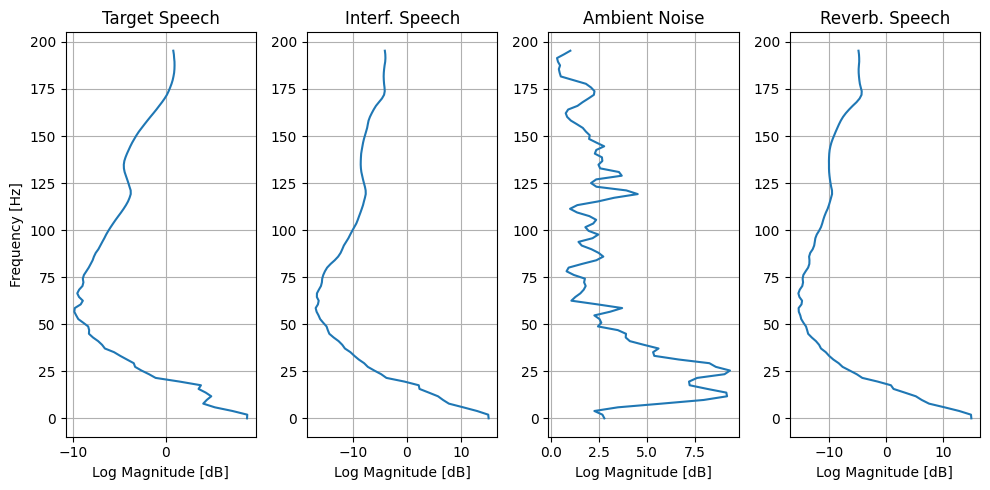

In [138]:
fft_freqs = torch.fft.rfftfreq(n=win_size, d=1/sr)

fig, axs = plt.subplots(1, 4, figsize=(10, 5))

# Up to 2000 Hz for better visualization.
axs[0].plot(avg_target_speech[:101].numpy(), fft_freqs[:101])
axs[0].set_xlabel("Log Magnitude [dB]")
axs[0].set_ylabel("Frequency [Hz]")
axs[0].grid()
axs[0].set_title("Target Speech")

axs[1].plot(avg_interf_speech[:101].numpy(), fft_freqs[:101])
axs[1].set_xlabel("Log Magnitude [dB]")
axs[1].grid()
axs[1].set_title("Interf. Speech")

axs[2].plot(avg_ambient_noise[:101].numpy(), fft_freqs[:101])
axs[2].set_xlabel("Log Magnitude [dB]")
axs[2].grid()
axs[2].set_title("Ambient Noise")

axs[3].plot(avg_reverb_speech[:101].numpy(), fft_freqs[:101])
axs[3].set_xlabel("Log Magnitude [dB]")
axs[3].grid()
axs[3].set_title("Reverb. Speech")

fig.tight_layout()
plt.show()

## Analyze EARS

In [8]:
path_db = r"/home/ovistetom/Documents/data/EARS/preprocessed/trn"
avg_spectrum = torch.zeros(win_size // 2 + 1)

for file_name in os.listdir(path_db):

    target_speech = os.path.join(path_db, file_name)
    waveform, sr = torchaudio.load(target_speech)
    waveform = waveform.mean(dim=0)
    # Normalize signal (zero mean and unit variance).
    waveform = (waveform - waveform.mean()) / waveform.std()
    specgram = stft(waveform)
    spectrum = specgram.mean(dim=-1)
    spectrum  = 10 * torch.log10(spectrum + 1e-10)
    avg_spectrum += spectrum

num_samples = len(os.listdir(path_db))
avg_spectrum /= num_samples

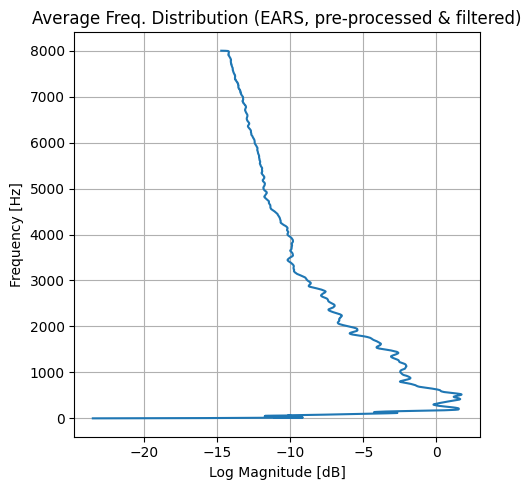

In [11]:
fft_freqs = torch.fft.rfftfreq(n=win_size, d=1/sr)
fig, axs = plt.subplots(1, 1, figsize=(5,5))
# Up to 2000 Hz for better visualization.
axs.plot(avg_spectrum.numpy(), fft_freqs)
axs.set_xlabel("Log Magnitude [dB]")
axs.set_ylabel("Frequency [Hz]")
axs.grid()
axs.set_title("Average Freq. Distribution (EARS, pre-processed & filtered)")

fig.tight_layout()
plt.show()

In [141]:
path_db = r"/home/ovistetom/Documents/data/EARS/original"
avg_spectrum = torch.zeros(win_size // 2 + 1)

for p_id in os.listdir(path_db):
    for file_name in os.listdir(os.path.join(path_db, p_id)):

        target_speech = os.path.join(path_db, p_id, file_name)
        waveform, sr = torchaudio.load(target_speech)
        waveform = waveform.mean(dim=0)
        # Normalize signal (zero mean and unit variance).
        waveform = (waveform - waveform.mean()) / waveform.std()
        specgram = stft(waveform)
        spectrum = specgram.mean(dim=-1)
        spectrum  = 10 * torch.log10(spectrum + 1e-10)
        avg_spectrum += spectrum

num_samples = len([file for root, dirs, files in os.walk(path_db) for file in files])
avg_spectrum /= num_samples

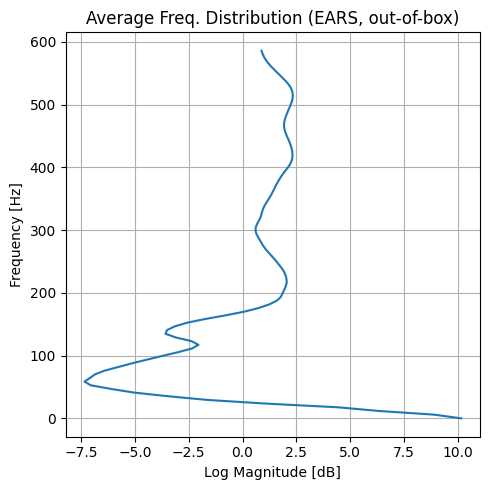

In [149]:
fft_freqs = torch.fft.rfftfreq(n=win_size, d=1/sr)
fig, axs = plt.subplots(1, 1, figsize=(5,5))

# Up to 2000 Hz for better visualization.
axs.plot(avg_spectrum[:101], fft_freqs[:101])
axs.set_xlabel("Log Magnitude [dB]")
axs.set_ylabel("Frequency [Hz]")
axs.grid()
axs.set_title("Average Freq. Distribution (EARS, out-of-box)")

fig.tight_layout()
plt.show()

 ## WHAM

In [167]:
path_db = r"/home/ovistetom/Documents/data/WHAM/preprocessed/trn"
avg_spectrum = torch.zeros(win_size // 2 + 1)

for file_name in os.listdir(path_db):

    target_speech = os.path.join(path_db, file_name)
    waveform, sr = torchaudio.load(target_speech)
    waveform = waveform.mean(dim=0)
    # Normalize signal (zero mean and unit variance).
    waveform = (waveform - waveform.mean()) / waveform.std()
    specgram = stft(waveform)
    spectrum = specgram.mean(dim=-1)
    spectrum  = 10 * torch.log10(spectrum + 1e-10)
    avg_spectrum += spectrum

num_samples = len(os.listdir(path_db))
avg_spectrum /= num_samples

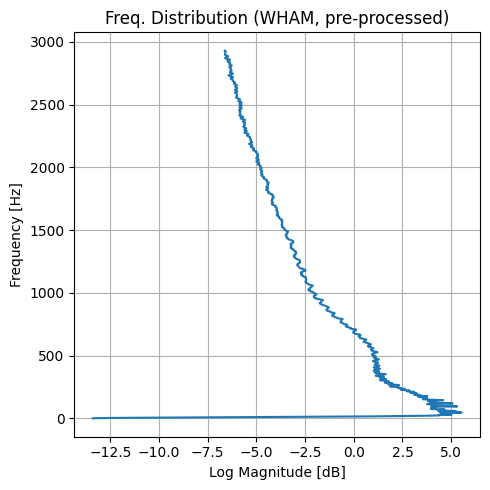

In [170]:
fft_freqs = torch.fft.rfftfreq(n=win_size, d=1/sr)
fig, axs = plt.subplots(1, 1, figsize=(5,5))
# Up to 2000 Hz for better visualization.
axs.plot(avg_spectrum[:1501], fft_freqs[:1501])
axs.set_xlabel("Log Magnitude [dB]")
axs.set_ylabel("Frequency [Hz]")
axs.grid()
axs.set_title("Freq. Distribution (WHAM, pre-processed)")

fig.tight_layout()
plt.show()

In [79]:
path_db = r"/home/ovistetom/Documents/data/WHAM/original/trn"
avg_spectrum = torch.zeros(win_size // 2 + 1)

for file_name in os.listdir(path_db):

    target_speech = os.path.join(path_db, file_name)
    waveform, sr = torchaudio.load(target_speech)
    waveform = waveform.mean(dim=0)
    # Normalize signal (zero mean and unit variance).
    waveform = (waveform - waveform.mean()) / waveform.std()
    specgram = stft(waveform)
    spectrum = specgram.mean(dim=-1)
    spectrum  = 10 * torch.log10(spectrum + 1e-10)
    avg_spectrum += spectrum

num_samples = len(os.listdir(path_db))
avg_spectrum /= num_samples


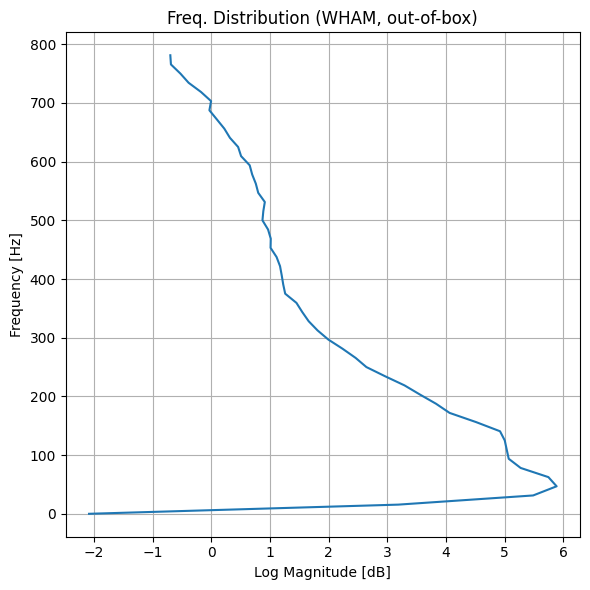

In [80]:
fft_freqs = torch.fft.rfftfreq(n=win_size, d=1/sr)
fig, axs = plt.subplots(1, 1, figsize=(6, 6))
# Up to 2000 Hz for better visualization.
axs.plot(avg_spectrum[:51].numpy(), fft_freqs[:51])
axs.set_xlabel("Log Magnitude [dB]")
axs.set_ylabel("Frequency [Hz]")
axs.grid()
axs.set_title("Freq. Distribution (WHAM, out-of-box)")

fig.tight_layout()
plt.show()